In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
bank = pd.read_excel(r'D:\Prog\ICRI\climate_change\raw_data\2025_World_Bank_classification.xlsx', 'List of economies', header=2)
bank

,Country,Code,Region,Income group,Classification
0,Afghanistan,AFG,South Asia,Low income,LIC
1,Albania,ALB,Europe & Central Asia,Upper middle income,UMIC
2,Algeria,DZA,Middle East & North Africa,Upper middle income,UMIC
3,American Samoa,ASM,East Asia & Pacific,High income,HIC
4,Andorra,AND,Europe & Central Asia,High income,HIC
...,...,...,...,...,...
213,Virgin Islands (U.S.),VIR,Latin America & Caribbean,High income,HIC
214,West Bank and Gaza,PSE,Middle East & North Africa,Lower middle income,LMIC
215,"Yemen, Rep.",YEM,Middle East & North Africa,Low income,LIC
216,Zambia,ZMB,Sub-Saharan Africa,Lower middle income,LMIC


In [7]:
test = pd.read_csv(r'..\co2_calc\emissions_v3\total_all.csv')
test

,Country,year,emissions
0,AFG,1990,1875.263718
1,AFG,1995,1601.205643
2,AFG,2000,1535.029465
3,AFG,2005,1423.286605
4,AFG,2010,1380.266919
...,...,...,...
171,SDN,2020,291.889527
172,SYR,2020,639.409673
173,TUN,2020,659.250688
174,YEM,2020,367.089431


In [10]:
for i in test['Country'].unique():
    if i not in bank['Code'].values:
        print(i)

EMR


In [11]:
test['income_group'] = test['Country'].map(bank.set_index('Code')['Income group'])
test

,Country,year,emissions,income_group
0,AFG,1990,1875.263718,Low income
1,AFG,1995,1601.205643,Low income
2,AFG,2000,1535.029465,Low income
3,AFG,2005,1423.286605,Low income
4,AFG,2010,1380.266919,Low income
...,...,...,...,...
171,SDN,2020,291.889527,Low income
172,SYR,2020,639.409673,Low income
173,TUN,2020,659.250688,Lower middle income
174,YEM,2020,367.089431,Low income


In [13]:
test['income_group'].value_counts()/8

income_group
Lower middle income    8.0
High income            6.0
Low income             5.0
Upper middle income    2.0
Name: count, dtype: float64

In [50]:
def grouper(df_path, name=None):
    test = pd.read_csv(df_path)
    try:
        test['income_group'] = test['Country'].map(bank.set_index('Code')['Income group'])
    except:
        test['income_group'] = test['iso3'].map(bank.set_index('Code')['Income group'])

    if name:
        test.to_csv(name, index=False)
    return test

In [16]:
t2 = grouper(r'..\diet_calc\scores\phdi\total_all.csv')
t2

,Country,1990,1995,2000,2005,2010,2015,2018,2020,income_group
0,AFG,73.0,71.5,68.0,68.0,72.0,71.0,74.0,NaN,Low income
1,ARE,56.5,52.0,53.5,67.0,75.5,76.0,72.0,NaN,High income
2,BHR,67.5,69.5,68.5,67.5,72.5,72.5,73.5,NaN,High income
3,DJI,60.0,67.0,73.5,75.0,63.0,74.0,69.0,NaN,Lower middle income
4,EGY,66.5,67.5,70.0,67.0,66.0,64.0,66.0,NaN,Lower middle income
5,IRN,65.5,64.5,67.5,68.5,71.5,71.5,74.5,NaN,Upper middle income
6,IRQ,69.0,82.0,66.5,67.0,68.0,58.0,65.5,NaN,Upper middle income
7,JOR,63.0,65.0,64.0,60.0,61.0,64.0,64.0,NaN,Lower middle income
8,KWT,64.0,56.5,56.0,63.5,61.5,60.0,61.0,NaN,High income
9,LBN,75.0,78.0,79.5,74.0,78.0,86.0,88.0,NaN,Lower middle income


In [21]:
t2.groupby('income_group').mean(numeric_only=True).round(2)

,1990,1995,2000,2005,2010,2015,2018,2020
income_group,,,,,,,,
High income,66.00,64.42,64.83,67.08,70.92,71.25,71.42,NaN
Low income,68.40,71.40,70.80,69.60,69.60,69.90,69.10,NaN
Lower middle income,64.25,65.62,66.69,66.25,65.56,68.12,68.50,NaN
Upper middle income,67.25,73.25,67.00,67.75,69.75,64.75,70.00,NaN


In [51]:
import os

pre = [
    (r'D:\Prog\ICRI\climate_change\co2_calc\emissions_v3\total_all.csv', 'emissions'),
    (r'..\diet_calc\scores\dash_dixon\total_all.csv', 'dash'),  # <--- Added missing comma
    (r'D:\Prog\ICRI\climate_change\diet_calc\scores\phdi\total_all.csv', 'phdi'),
    (r'D:\Prog\ICRI\climate_change\diet_calc\scores\medit_new\total_all.csv', 'medit')
]

# Create the folder safely (won't crash if it already exists)
os.makedirs('processed', exist_ok=True)

for i, j in pre:
    # Construct filename correctly: processed/emissions.csv
    outpath = os.path.join('processed', f'{j}.csv')
    grouper(i, outpath)

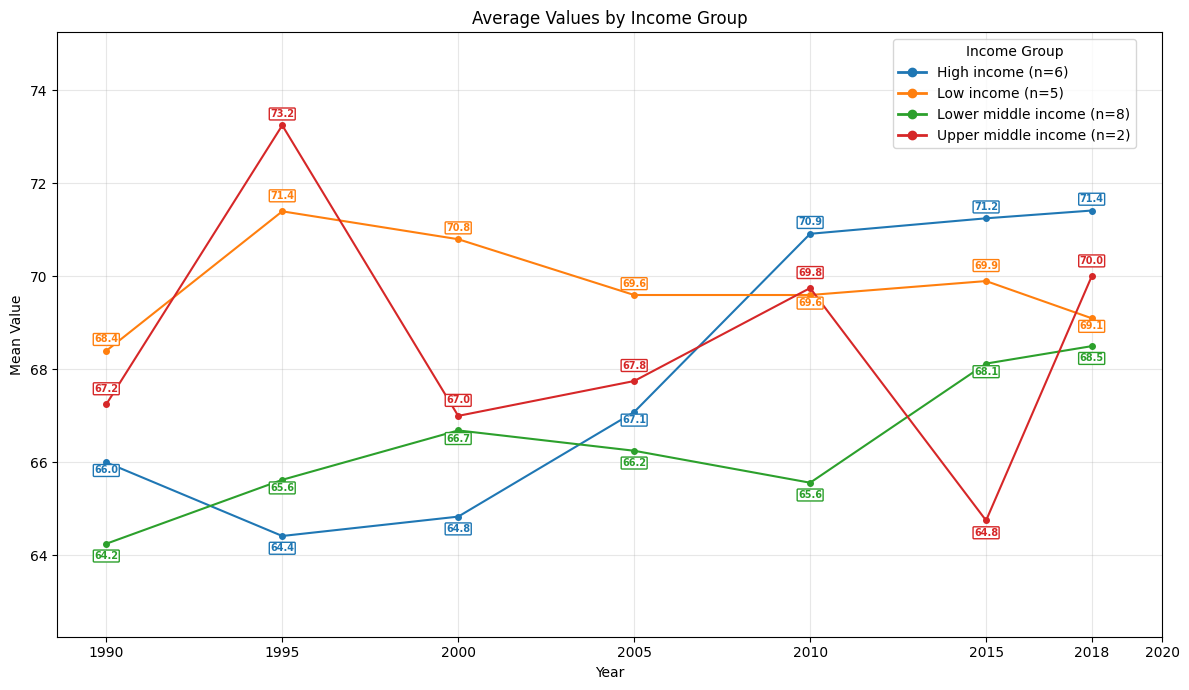

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from typing import List, Dict

# ---------------------------------------------------------
# 1. Helper Function: Tight Annotations
# ---------------------------------------------------------
def _annotate_tight(
    ax: plt.Axes,
    entries: List[Dict],
    offset_up: int = 6,    # Very close to the dot (pixels)
    offset_down: int = -8  # Very close (slightly more to clear text height)
):
    groups: Dict[int, List[Dict]] = {}
    for e in entries:
        groups.setdefault(int(e["year"]), []).append(e)

    for year, items in groups.items():
        # Sort values so we know which is "top" and which is "bottom"
        items_sorted = sorted(items, key=lambda x: x["value"], reverse=True)
        
        # Simple split: Top half labels go UP, bottom half labels go DOWN
        mid = (len(items_sorted) + 1) // 2
        above_items = items_sorted[:mid]
        below_items = items_sorted[mid:]

        # Annotate Top items (slightly above line)
        for i, it in enumerate(above_items):
            # We add a tiny extra nudge (i*3) only if multiple points are stacked 
            # to prevent the boxes from overlapping each other perfectly
            nudge = offset_up + (i * 3) 
            
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, nudge),
                ha="center",
                fontsize=7,  # Small font to keep it tight
                fontweight='bold',
                color=it["color"],
                # Small padding (0.1) to reduce white box size
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=1.0),
                zorder=10
            )

        # Annotate Bottom items (slightly below line)
        for i, it in enumerate(below_items):
            nudge = offset_down - (i * 3)
            
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, nudge),
                ha="center",
                fontsize=7,
                fontweight='bold',
                color=it["color"],
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=1.0),
                zorder=10
            )

# ---------------------------------------------------------
# 2. Plotting
# ---------------------------------------------------------

# Prepare data
means = t2.groupby('income_group').mean(numeric_only=True).T
years = means.index.astype(int)
group_names = means.columns
counts = t2['income_group'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
color_map = {name: col for name, col in zip(group_names, colors)}

entries_for_annotation = []
legend_handles = []

for name in group_names:
    color = color_map[name]
    y_mean = means[name]
    n_count = counts.get(name, 0)
    label_str = f"{name} (n={n_count})"
    
    # Plot Line
    ax.plot(
        years, y_mean, 
        marker='o', markersize=4, # Smaller marker
        color=color, linewidth=1.5, 
        label=label_str
    )
    
    # Collect data
    for yr, val in zip(years, y_mean):
        entries_for_annotation.append({
            "year": yr,
            "value": val,
            "text": f"{val:.1f}", 
            "color": color
        })
        
    legend_handles.append(Line2D([0], [0], color=color, marker='o', lw=2, label=label_str))

# ---------------------------------------------------------
# 3. Apply Styling
# ---------------------------------------------------------

_annotate_tight(ax, entries_for_annotation)

ax.set_title('Average Values by Income Group')
ax.set_ylabel('Mean Value')
ax.set_xlabel('Year')
ax.set_xticks(years)


# Auto-scale Y with small margin
y_min, y_max = means.min().min(), means.max().max()
ax.set_ylim(y_min - 2, y_max + 2) 

ax.grid(alpha=0.3)
ax.legend(handles=legend_handles, title='Income Group', bbox_to_anchor=(0.75, 1), loc='upper left')
plt.set_cmap('Blues')
plt.tight_layout()
plt.show()

In [2]:


df_co2 = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\emissions.csv').dropna(subset=['income_group'])
df_dash = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\dash.csv').dropna(subset=['income_group'])
df_phdi = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\phdi.csv').dropna(subset=['income_group'])
df_medit = pd.read_csv(r'D:\Prog\ICRI\climate_change\paper_2\processed\medit.csv').dropna(subset=['income_group'])

In [6]:
import os
from typing import List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.cm as cm

# -------------------------------------------------------------------------
# DATA PROCESSING HELPERS
# -------------------------------------------------------------------------

def _process_diet_data(df: pd.DataFrame, n_years: int = 7) -> pd.DataFrame:
    """
    Handles 'Wide' format data (Diet scores) where years are columns.
    Returns: DataFrame with [year, mean, ci_lo, ci_hi]
    """
    try:
        data_cols = df.columns[1:1 + n_years]
        cols_as_int = data_cols.astype(int)
    except Exception:
        data_cols = [c for c in df.columns if str(c).isdigit()][:n_years]
    
    if len(data_cols) == 0:
        return pd.DataFrame()

    mean = df[data_cols].mean(axis=0, numeric_only=True)
    std = df[data_cols].std(axis=0, ddof=1, numeric_only=True)
    n = df[data_cols].count(axis=0)
    
    se = std / np.sqrt(n.replace(0, np.nan))
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se

    out_df = pd.DataFrame({
        "year": data_cols.astype(int),
        "mean": mean.values,
        "ci_lo": ci_lo.values,
        "ci_hi": ci_hi.values,
    })
    
    out_df["ci_lo"] = out_df["ci_lo"].fillna(out_df["mean"])
    out_df["ci_hi"] = out_df["ci_hi"].fillna(out_df["mean"])
    
    return out_df


def _process_co2_data(df: pd.DataFrame, n_rows: int = 7) -> pd.DataFrame:
    """
    Handles 'Long' format data (CO2).
    """
    if "year" not in df.columns or "emissions" not in df.columns:
        raise ValueError("CO2 DataFrame must contain 'year' and 'emissions' columns")

    grp = df.groupby("year")["emissions"]
    years = sorted(grp.groups.keys())
    
    rows = []
    target_years = years[:n_rows] if n_rows else years

    for y in target_years:
        s = grp.get_group(y).dropna()
        n = len(s)
        m = s.mean()
        
        if n > 1:
            sd = s.std(ddof=1)
            se = sd / np.sqrt(n)
            ci_half = 1.96 * se
        else:
            ci_half = 0

        rows.append({
            "year": int(y),
            "mean": m,
            "ci_lo": m - ci_half,
            "ci_hi": m + ci_half,
        })
    
    return pd.DataFrame(rows)


# -------------------------------------------------------------------------
# ANNOTATION HELPER
# -------------------------------------------------------------------------

def _annotate_grouped(
    ax: plt.Axes,
    entries: List[Dict],
    start_up: int = 10,
    start_down: int = -10
):
    groups: Dict[int, List[Dict]] = {}
    for e in entries:
        groups.setdefault(int(e["year"]), []).append(e)

    for year, items in groups.items():
        items_sorted = sorted(items, key=lambda x: x["value"], reverse=True)
        mid = (len(items_sorted) + 1) // 2
        above_items = items_sorted[:mid]
        below_items = items_sorted[mid:]

        for i, it in enumerate(above_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_up + (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )

        for i, it in enumerate(below_items, start=1):
            ax.annotate(
                it["text"],
                (it["year"], it["value"]),
                textcoords="offset points",
                xytext=(0, start_down - (i * 2)),
                ha="center",
                fontsize=8,
                color=it["color"],
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.1", edgecolor=it["color"], facecolor="white", alpha=0.8)
            )

# -------------------------------------------------------------------------
# MAIN PLOTTING FUNCTION
# -------------------------------------------------------------------------

def plot_shaded_four_panel(
    df_co2: pd.DataFrame,
    df_phdi: pd.DataFrame,
    df_dash: pd.DataFrame,
    df_medit: pd.DataFrame,
    n_years: int = 7,
    figsize=(10, 14),
    dpi: int = 300,
    output_folder: str = "figures"
):
    """
    Plots 4 panels with consistent colors, upper-left legends including counts, and no shading.
    """

    # --- 1. Identify all unique income groups safely ---
    all_groups = set()
    for df in [df_co2, df_phdi, df_dash, df_medit]:
        if "income_group" in df.columns:
            uniques = df["income_group"].dropna().unique()
            all_groups.update(uniques)
    
    # Sort safely (strings)
    valid_groups = [g for g in all_groups if pd.notna(g)]
    sorted_groups = sorted(valid_groups, key=lambda x: str(x))
    
    # --- 2. Color Map Setup ---
    cmap = plt.get_cmap("tab10" if len(sorted_groups) <= 10 else "tab20")
    group_colors = {grp: cmap(i) for i, grp in enumerate(sorted_groups)}

    # --- 3. Setup Plot ---
    fig, axes = plt.subplots(4, 1, figsize=figsize, dpi=dpi, sharex=True)
    ax_co2, ax_phdi, ax_dash, ax_medit = axes

    # Configuration: (Axis, DataFrame, Metric Name, Type, YLabel, Title, YLim)
    configs = [
        (ax_co2, df_co2, "co2", "long", "CO₂ Emissions (g)", "CO₂ Emissions", None),
        (ax_phdi, df_phdi, "phdi", "wide", "PHDI Score", "Planetary Health Diet Index", (55, 80)),
        (ax_dash, df_dash, "dash", "wide", "DASH Score", "DASH Diet Scores", (0, 3)),
        (ax_medit, df_medit, "medit", "wide", "Medit Score", "Mediterranean Diet Scores", (0, 5))
    ]

    # --- 4. Plotting Loop ---
    for ax, df, name, data_type, ylabel, title, ylim in configs:
        
        annotation_entries = []
        years_in_plot = set()
        group_counts = {}  # Store counts to build legend later
        
        if "income_group" not in df.columns:
            print(f"Warning: 'income_group' column missing in {name}. Skipping.")
            continue

        for group_name, group_df in df.groupby("income_group"):
            
            if group_name not in group_colors:
                continue

            color = group_colors[group_name]
            
            # --- CALCULATE N FOR LEGEND ---
            if data_type == "long":
                # For long data, rows are year-country pairs. 
                # N = Average number of countries per year (approx) or unique entities if ID existed
                # Here we use: Total Rows / Unique Years to approximate 'N' subjects
                n_years_data = group_df['year'].nunique()
                n_count = int(len(group_df) / n_years_data) if n_years_data > 0 else 0
            else:
                # For wide data, rows = subjects
                n_count = len(group_df)
            
            group_counts[group_name] = n_count

            # Process Data
            if data_type == "long":
                stats = _process_co2_data(group_df, n_rows=n_years)
                val_fmt = lambda x: f"{int(x)}"
                marker = "o"
            else:
                stats = _process_diet_data(group_df, n_years=n_years)
                val_fmt = lambda x: f"{x:.1f}"
                marker = "s" if name in ["dash", "phdi"] else "v"

            if stats.empty:
                continue

            years_in_plot.update(stats["year"].tolist())

            # Plot Line & Markers (NO SHADING)
            ax.plot(stats["year"], stats["mean"], marker=marker, color=color, label=str(group_name))
            
            # Collect points for annotation
            for _, r in stats.iterrows():
                annotation_entries.append({
                    "year": r["year"],
                    "value": r["mean"],
                    "text": val_fmt(r["mean"]),
                    "color": color
                })

        # Apply Axis Settings
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(alpha=0.3)
        if ylim:
            ax.set_ylim(ylim)
        
        # Set X Ticks
        if years_in_plot:
            sorted_years = sorted(list(years_in_plot))
            ax.set_xticks(sorted_years)
            ax.set_xticklabels([int(y) for y in sorted_years])
        
        if name == "co2":
            ax.axvline(x=2018, color="lightgray", linestyle="--", linewidth=0.7)

        # Annotate
        _annotate_grouped(ax, annotation_entries)
        
        # --- BUILD LEGEND WITH COUNTS ---
        handles = []
        # Iterate through sorted_groups to maintain consistent order across plots
        for grp in sorted_groups:
            if grp in group_counts:
                c = group_colors[grp]
                count = group_counts[grp]
                label_text = f"{grp} (n={count})"
                h = Line2D([0], [0], color=c, marker='o', label=label_text)
                handles.append(h)
        
        if handles:
            ax.legend(handles=handles,  title='Income Group', bbox_to_anchor=(0.75, 1), loc="upper left", fontsize=9, framealpha=0.9)


    plt.tight_layout()
    
    os.makedirs(output_folder, exist_ok=True)
    out_path = os.path.join(output_folder, "income_group_comparison.png")
    plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print(f"Plot saved to {out_path}")
    plt.show()

Plot saved to figures\income_group_comparison.png


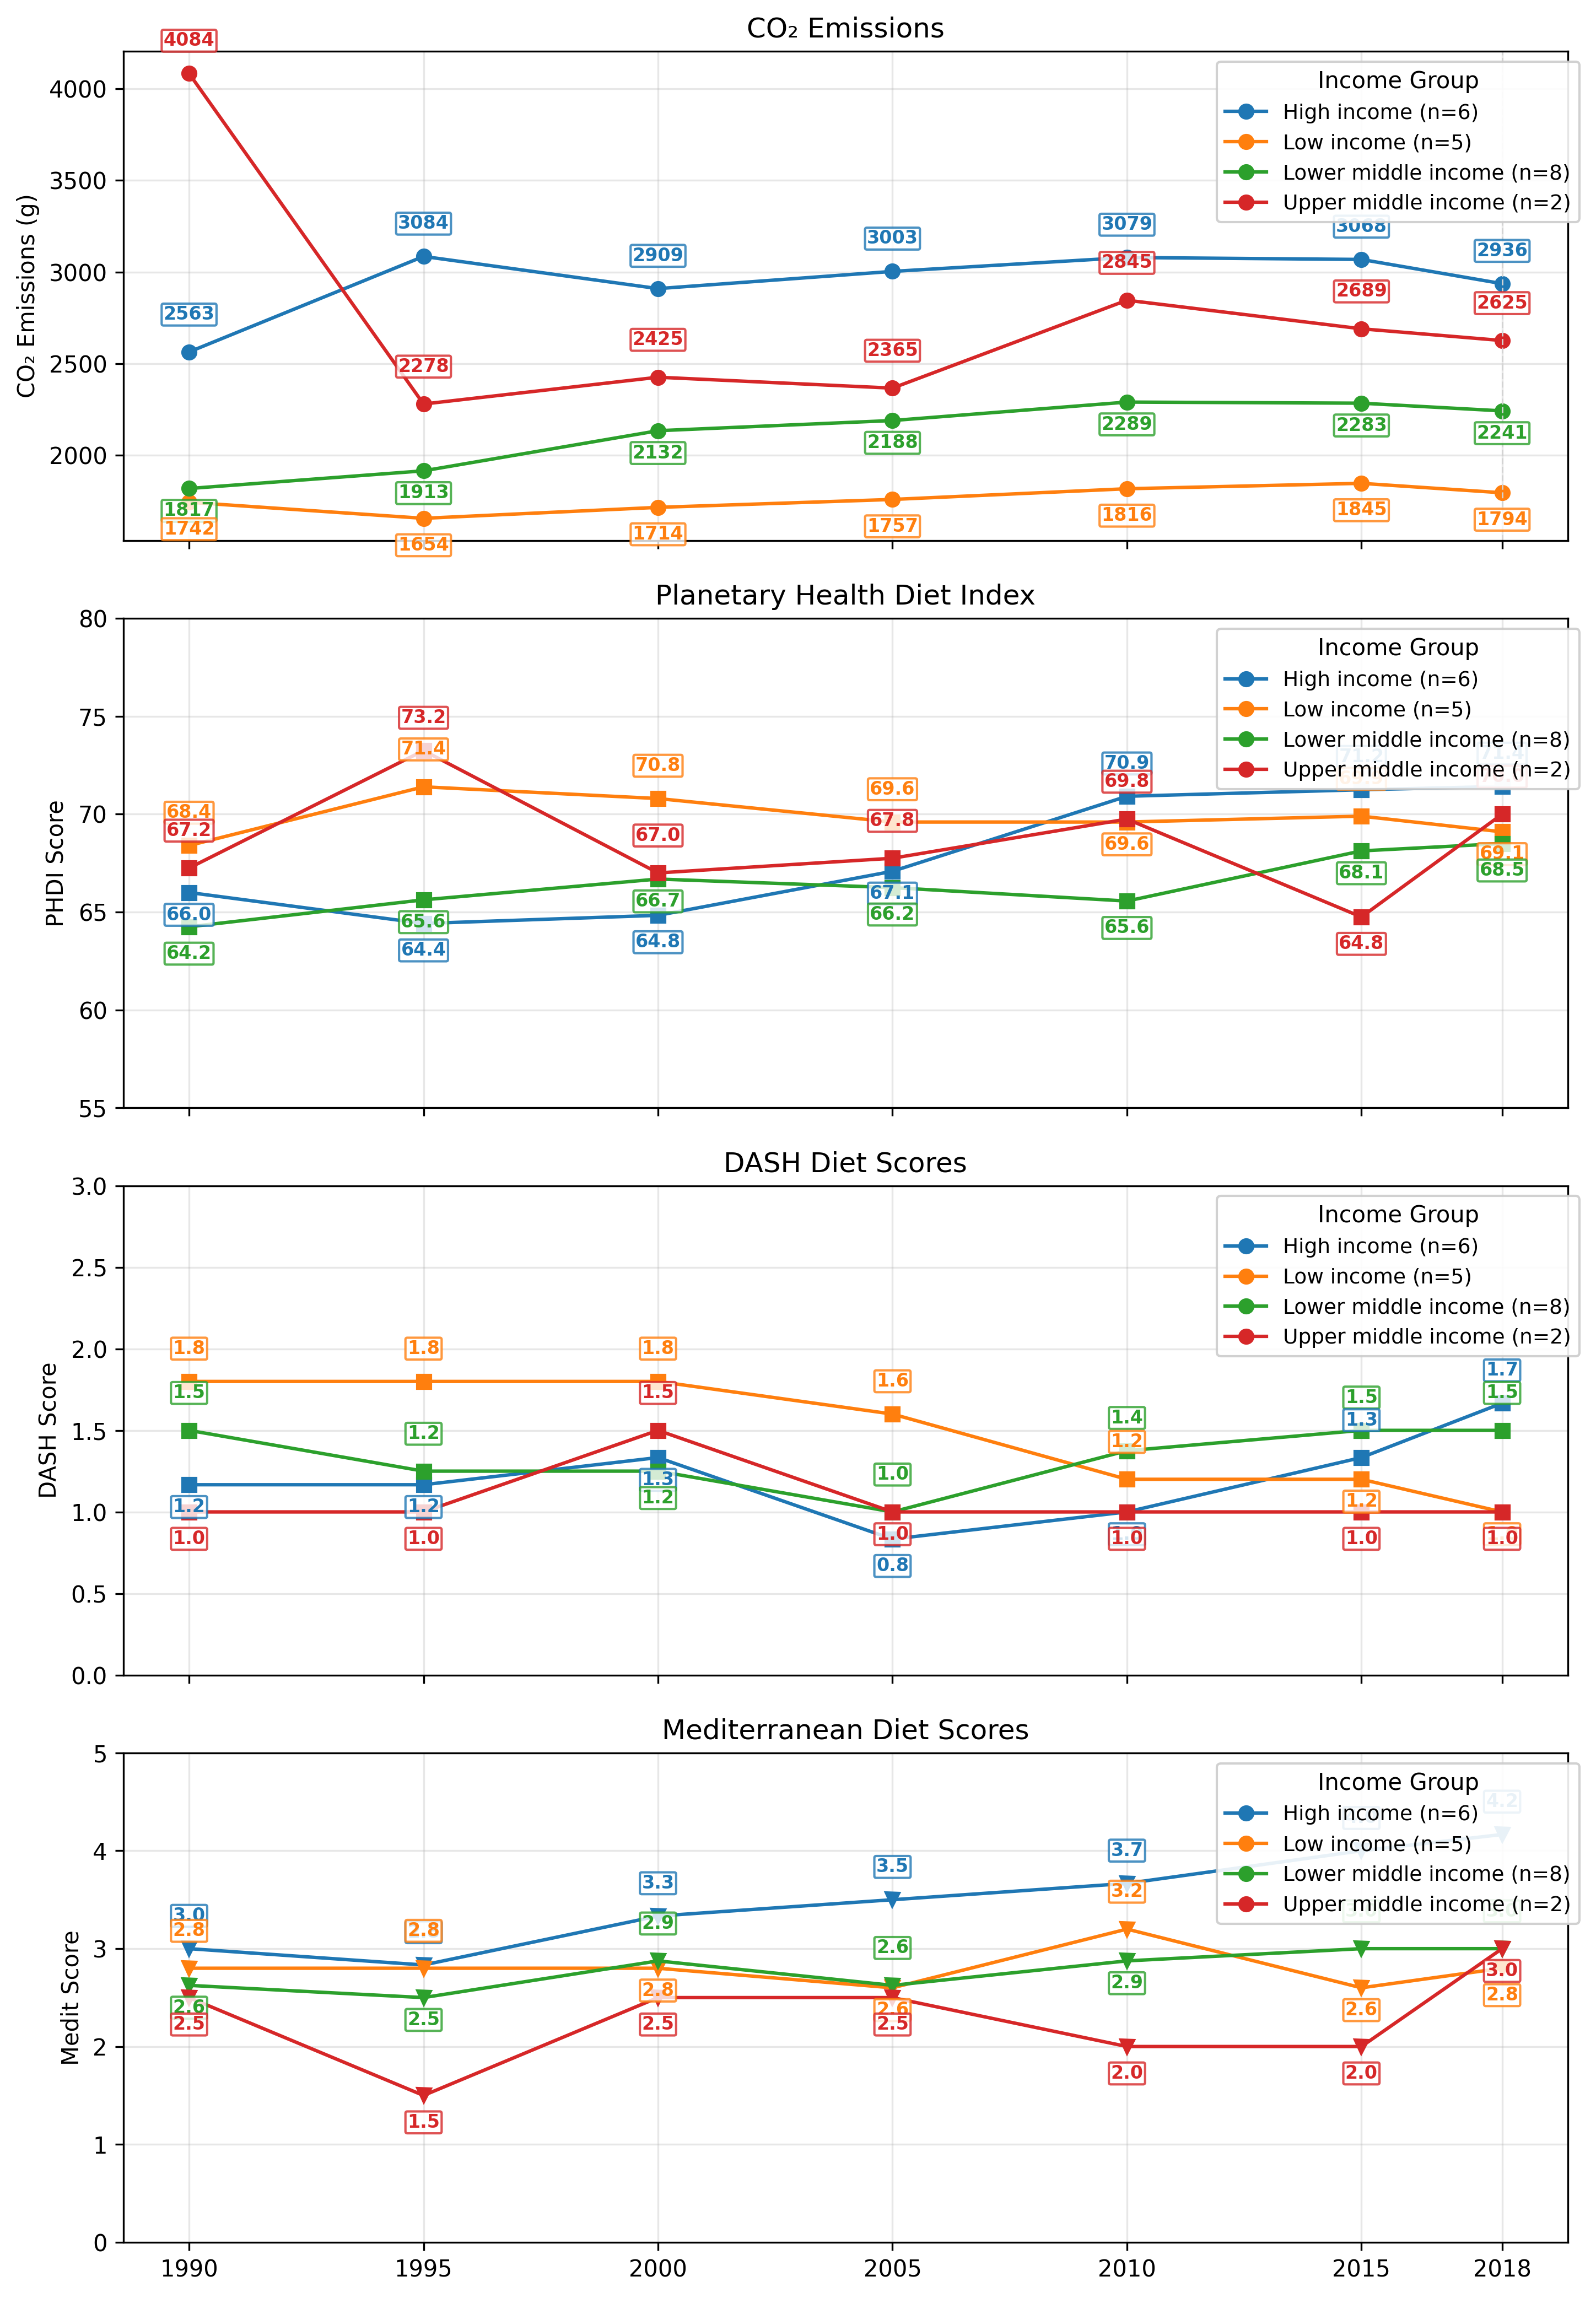

In [7]:
plot_shaded_four_panel(
    df_co2=df_co2,   # Must have: income_group, year, emissions
    df_phdi=df_phdi, # Must have: income_group, 2010, 2015...
    df_dash=df_dash, # Must have: income_group, 2010, 2015...
    df_medit=df_medit, # Must have: income_group, 2010, 2015...
    n_years=7
)